# Import libraries

In [279]:
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

In [280]:
SHIFT = 3

# Load data

In [281]:
df = pd.read_parquet("../data/merged_data.parquet")

# Feature engineering

## Missing values

In [282]:
df = df.iloc[28000:]

In [283]:
df = df.drop("wind_gust", axis=1)
df = df.dropna(subset="temp")

In [284]:
df = df.ffill()

## Date features

In [285]:
def is_weekend(day_of_week: int) -> int:
    match day_of_week:
        case 0 | 7:
            return 1
        case _:
            return 0
        
def is_new_years(timestamp) -> bool:
    if ((timestamp.month == 12 and timestamp.day_of_week == 31) 
        or 
        (timestamp.month == 1 and timestamp.day_of_week == 1)):
        return True
    else:
        return False

In [286]:
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.day_of_week
df['hour_of_day'] = df['timestamp'].dt.hour
df['is_weekend'] = df['day_of_week'].apply(lambda day: is_weekend(day))
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['month_sin'] = np.sin(2* np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2* np.pi * df['month'] / 12)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['is_new_year'] = df["timestamp"].apply(lambda x: is_new_years(x))

## Rolling & lag

In [287]:
df = df.rename(columns={"value": "pm25"})

In [288]:
df.columns

Index(['pm25', 'timestamp', 'temp', 'feels_like', 'pressure', 'humidity',
       'dew_point', 'wind_speed', 'wind_deg', 'year', 'month', 'day_of_week',
       'hour_of_day', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin',
       'month_cos', 'day_sin', 'day_cos', 'is_new_year'],
      dtype='object')

In [289]:
target = 'pm25'
targets = ["pm25", "temp", "feels_like", "pressure", "humidity", "wind_speed"]
lag_periods = [3, 6, 12]
rolling_window = [3, 6]

In [290]:
for targ in targets:
    for window in rolling_window:
        df[f'rolling_{targ}_{str(window)}'] = df[targ].rolling(window=window).mean()

    for period in lag_periods:
        df[f'lag_{targ}_{str(period)}'] = df[targ].shift(periods=period)

df['wind_deg_sin'] = np.sin(2 * np.pi * df['wind_deg'] / 360)
df['wind_deg_cos'] = np.cos(2 * np.pi * df['wind_deg'] / 360)

## Shifted target

In [291]:
df['target'] = df[target].shift(-SHIFT)

# Create data splits

In [292]:
df = df.dropna()
df.shape

(24465, 54)

In [293]:
assert ~df.isna().sum(axis=0).any(), "Still contains nulls"

In [294]:
train_idx = int(np.ceil(len(df) * .9))
print(train_idx)

22019


In [295]:
train_df = df.iloc[:train_idx, :]
test_df = df.iloc[train_idx:, :]
print(train_df.shape, test_df.shape)

(22019, 54) (2446, 54)


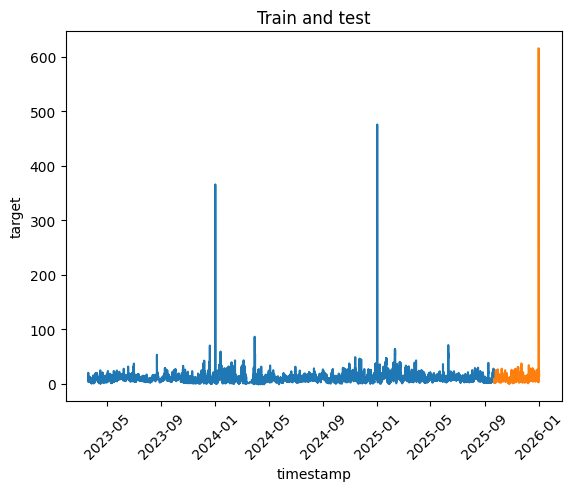

In [296]:
sns.lineplot(train_df, x="timestamp", y="target")
sns.lineplot(test_df, x="timestamp", y="target")
plt.title("Train and test")
plt.xticks(rotation=45)
plt.show()

In [297]:
X_train = train_df.drop(['timestamp', 'target'], axis=1)
y_train = train_df.loc[:, 'target']

X_test = test_df.drop(['timestamp', 'target'], axis=1)
y_test = test_df.loc[:, 'target']

train_timestamp = train_df.loc[:, 'timestamp']
test_timestamp = test_df.loc[:, 'timestamp']

# Train model

## Baseline (Ridge)

In [298]:
clf = Ridge(alpha=1.0)
clf.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [299]:
y_hat = clf.predict(X_test)
mae = mean_absolute_error(y_test, y_hat)
r2 = r2_score(y_test, y_hat)

print("MAE", mae)
print("r2", r2)

MAE 3.3404078729258653
r2 0.011247929560273762


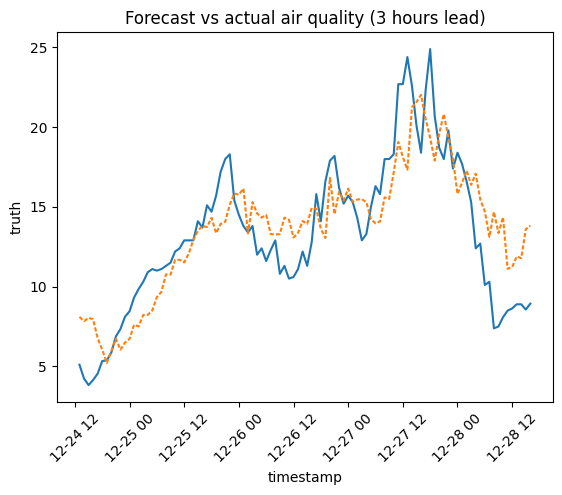

In [300]:
y_hat_df = pd.DataFrame(
    data={
        "timestamp": test_timestamp,
        "truth": y_test,
        "pred": y_hat
    }
)

sns.lineplot(y_hat_df[-200:-100], x="timestamp", y="truth")
sns.lineplot(y_hat_df[-200:-100], x="timestamp", y="pred", dashes=[2, 1])

plt.title("Forecast vs actual air quality (3 hours lead)")
plt.xticks(rotation=45)
plt.show()

In [301]:
y_hat_df.head()

,timestamp,truth,pred
50183,2025-09-21 23:00:00+00:00,2.83,5.825094
50184,2025-09-22 00:00:00+00:00,3.05,6.208681
50185,2025-09-22 01:00:00+00:00,3.04,5.524944
50186,2025-09-22 02:00:00+00:00,3.20,5.537655
50187,2025-09-22 03:00:00+00:00,3.12,5.812813


In [302]:
pd.DataFrame(data={
    "coef": clf.coef_,
    "feature": clf.feature_names_in_
}) \
    .sort_values('coef', ascending=False) \
    .reset_index() \
    .drop('index', axis=1)

,coef,feature
0,0.573794,pm25
1,0.541340,rolling_feels_like_3
2,0.505631,wind_deg_cos
3,0.495628,wind_deg_sin
4,0.483579,is_new_year
5,0.396083,month_cos
6,0.263861,lag_feels_like_12
7,0.195198,year
8,0.185837,lag_feels_like_6
9,0.130325,rolling_wind_speed_3


In [303]:
df.groupby('month').agg({
    'target': 'mean'
})

,target
month,
1,13.559834
2,14.341520
3,9.739279
4,8.549120
5,9.095426
6,10.765481
7,8.601989
8,9.973011
9,9.067301


# Final remarks
At the end of this experiment, we observe the following:
- Removing lag and rolling features makes model **useless** (worth than guessing)
- As such, current features (temperature, humidity and temporal features) **do not** have significant explanatory power.
- Further feature engineering is required. Likely candidates:
    - Wind
    - Pressure

# LightGBM

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001844 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8696
[LightGBM] [Info] Number of data points in the train set: 22019, number of used features: 52
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [I

/home/luc/Documents/Projects/air_quality/.venv/lib/python3.10/site-packages/lightgbm/callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
R2 Score: 0.1117
RMSE: 203.7006


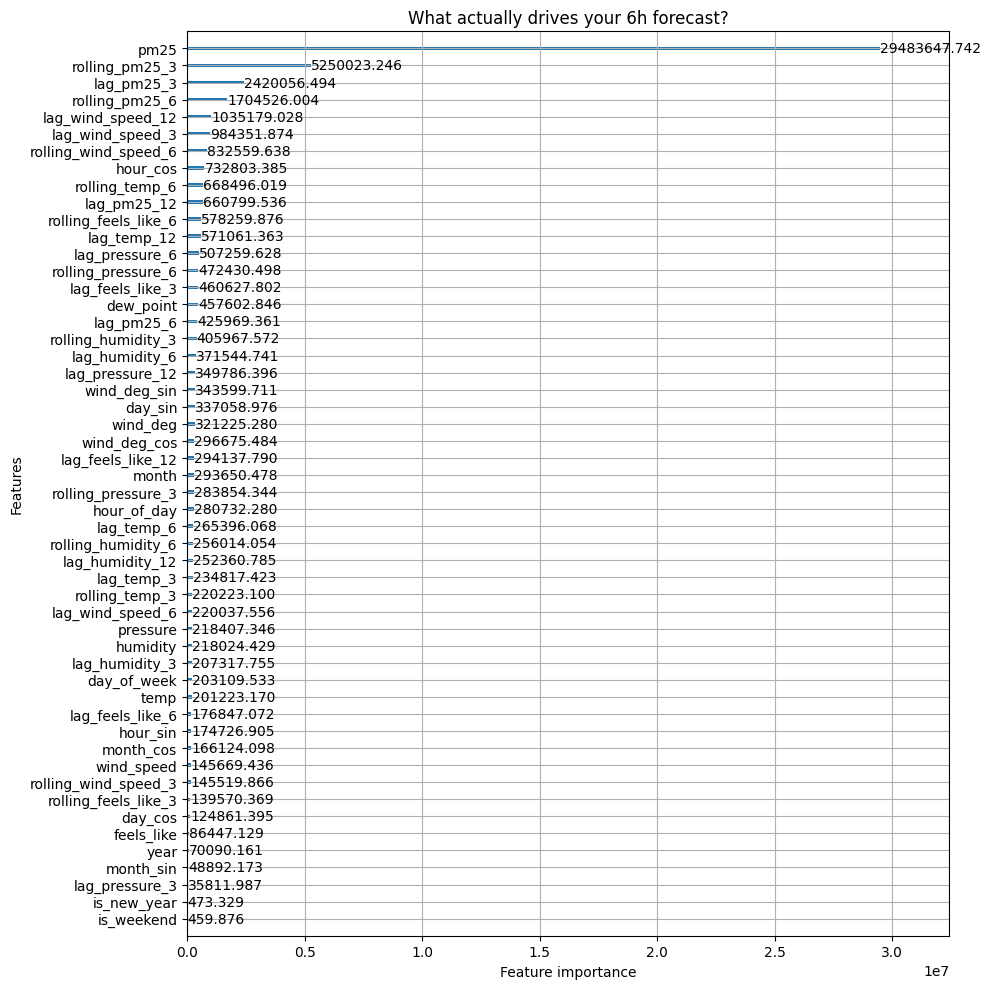

In [304]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

model = lgb.LGBMRegressor(
    boosting_type='dart',
    objective='regression',
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=1000,      
    feature_fraction=0.8,   
    bagging_fraction=0.7,   
    bagging_freq=5,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2',
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

lgb.plot_importance(model, importance_type='gain', figsize=(10, 10))
plt.title("What actually drives your 6h forecast?")
plt.tight_layout()
plt.show()

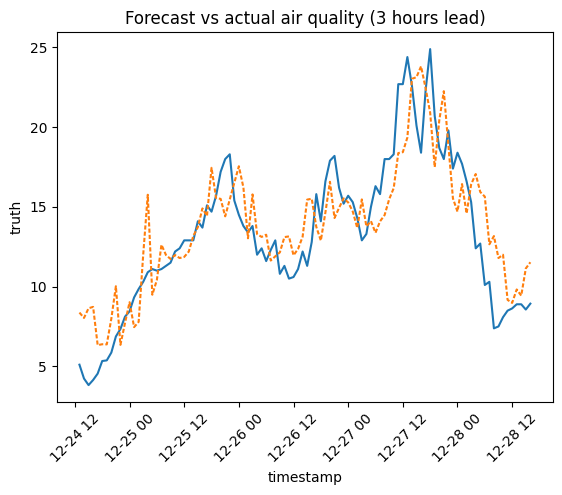

In [305]:
y_hat_df = pd.DataFrame(
    data={
        "timestamp": test_timestamp,
        "truth": y_test,
        "pred": y_pred
    }
)

sns.lineplot(y_hat_df[-200:-100], x="timestamp", y="truth")
sns.lineplot(y_hat_df[-200:-100], x="timestamp", y="pred", dashes=[2, 1])

plt.title("Forecast vs actual air quality (3 hours lead)")
plt.xticks(rotation=45)
plt.show()

# Prophet

In [306]:
from prophet import Prophet

In [307]:
prophet_df = df.loc[:, ["timestamp", "pm25"]]
prophet_df = prophet_df.rename(columns={"timestamp":"ds", "pm25":"y"})

In [308]:
prophet_df['ds'] = prophet_df['ds'].dt.tz_localize(None)

In [309]:
m = Prophet()
m.fit(prophet_df)

11:53:53 - cmdstanpy - INFO - Chain [1] start processing
11:54:00 - cmdstanpy - INFO - Chain [1] done processing


In [310]:
# Python
future = m.make_future_dataframe(periods=48)
future.tail()

,ds
24508,2026-02-14 20:00:00
24509,2026-02-15 20:00:00
24510,2026-02-16 20:00:00
24511,2026-02-17 20:00:00
24512,2026-02-18 20:00:00


In [311]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
24508,2026-02-14 20:00:00,31.274096,18.939360,43.624915
24509,2026-02-15 20:00:00,30.117658,17.135525,43.205086
24510,2026-02-16 20:00:00,31.065195,18.573062,44.587513
24511,2026-02-17 20:00:00,31.373719,17.939304,44.708726
24512,2026-02-18 20:00:00,31.390094,17.556994,44.141074


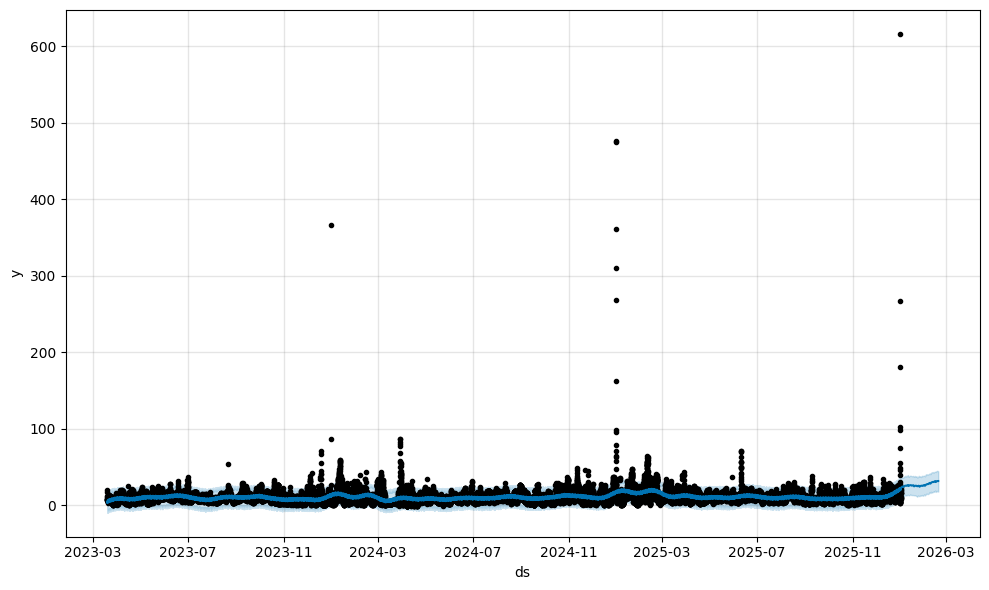

In [312]:
fig1 = m.plot(forecast)

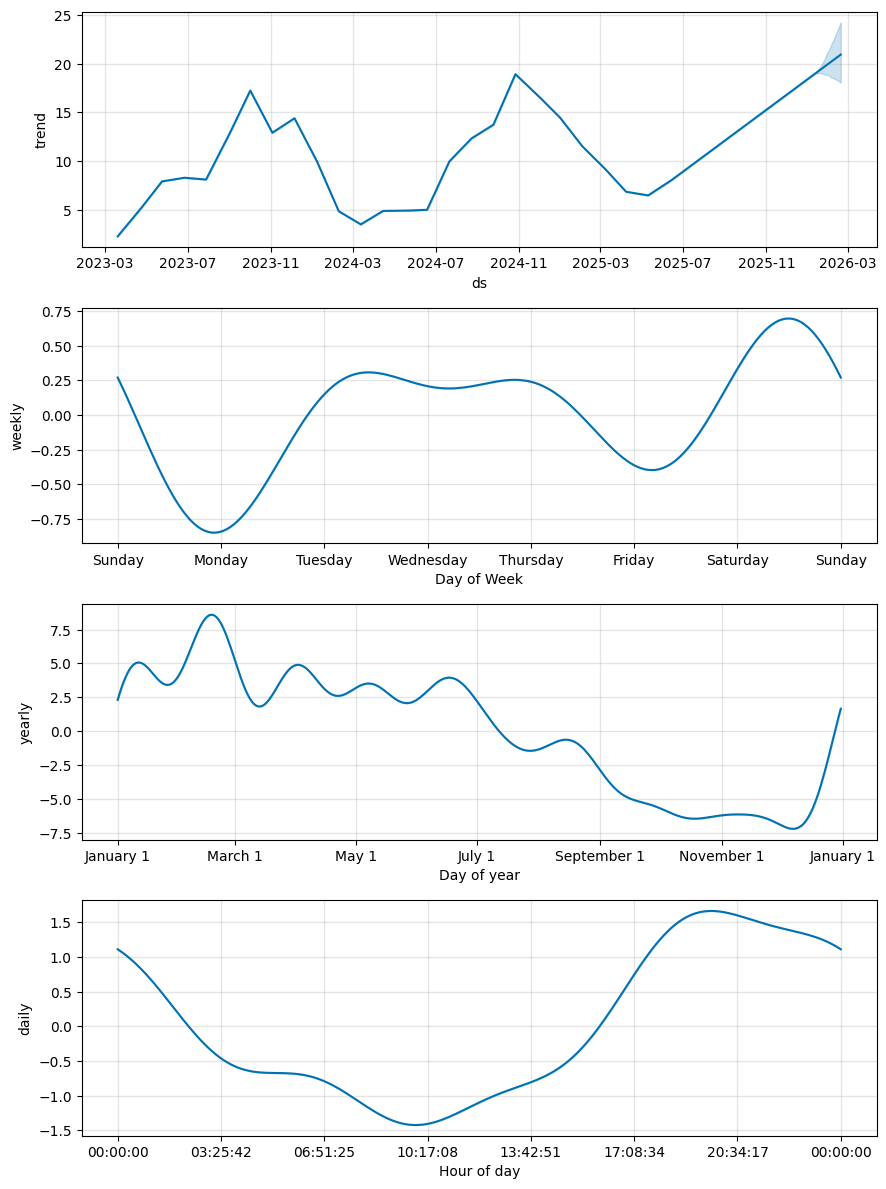

In [313]:
fig2 = m.plot_components(forecast)

In [314]:
df.describe()

,pm25,temp,feels_like,pressure,humidity,dew_point,wind_speed,wind_deg,year,month,...,lag_humidity_6,lag_humidity_12,rolling_wind_speed_3,rolling_wind_speed_6,lag_wind_speed_3,lag_wind_speed_6,lag_wind_speed_12,wind_deg_sin,wind_deg_cos,target
count,24465.000000,24465.000000,24465.000000,24465.000000,24465.000000,24465.000000,24465.000000,24465.000000,24465.000000,24465.000000,...,24465.000000,24465.000000,24465.000000,24465.000000,24465.000000,24465.000000,24465.000000,24465.000000,24465.000000,24465.000000
mean,10.104673,284.542786,283.909824,1017.039853,79.142571,280.616926,1.623311,191.359902,2024.077744,6.873207,...,79.146863,79.152953,1.623220,1.623110,1.623037,1.622927,1.622642,-0.152234,-0.056012,10.105954
std,10.136853,8.108844,8.621571,8.261821,16.145452,6.338950,1.133460,94.528522,0.798444,3.313435,...,16.142802,16.138031,0.924195,0.824151,1.133323,1.133321,1.133087,0.792387,0.588090,10.137118
min,-1.000000,260.650000,255.170000,980.000000,22.000000,259.610000,0.020000,0.000000,2023.000000,1.000000,...,22.000000,22.000000,0.133333,0.175000,0.020000,0.020000,0.020000,-1.000000,-1.000000,-1.000000
25%,5.420000,278.560000,277.540000,1012.000000,69.000000,275.800000,0.890000,104.000000,2023.000000,4.000000,...,69.000000,69.000000,0.986667,1.060000,0.890000,0.890000,0.890000,-0.933580,-0.559193,5.420000
50%,8.660000,284.230000,283.550000,1017.000000,85.000000,280.760000,1.340000,216.000000,2024.000000,7.000000,...,85.000000,85.000000,1.430000,1.440000,1.340000,1.340000,1.340000,-0.453990,-0.034899,8.660000
75%,12.800000,290.070000,289.900000,1022.000000,92.000000,285.600000,2.240000,273.000000,2025.000000,10.000000,...,92.000000,92.000000,2.010000,1.938333,2.240000,2.240000,2.240000,0.754710,0.406737,12.800000
max,616.000000,308.740000,309.440000,1044.000000,100.000000,295.210000,19.620000,360.000000,2026.000000,12.000000,...,100.000000,100.000000,8.940000,8.195000,19.620000,19.620000,19.620000,1.000000,1.000000,616.000000
